In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akram24/social-network-ads")

print("Path to dataset files:", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 6.93MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/akram24/social-network-ads/versions/1


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path + "/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df["Purchased"].value_counts()

,count
Purchased,
0,257
1,143


In [6]:
## classification problem
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
## standardizing the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
x = df.iloc[:,2:4]
y = df.iloc[:,-1]

In [34]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [17]:
x_scaled = scaler.fit_transform(x)

In [19]:
x_scaled.shape

(400, 2)

In [20]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
import time

1. Total Samples: Your dataset x_scaled has 400 samples (as shown by x_scaled.shape being (400, 2)).
2. Training Split: You used a validation_split of 0.2, meaning 20% of the data (80 samples) is reserved for validation, and the remaining 80% (320 samples) is used for training.

In [55]:
## STOCHASTIC GRADIENT DESCENT
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history1 = model.fit(x_scaled,y,epochs=500,batch_size=1,validation_split=0.2)
print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9125 - loss: 0.2163 - val_accuracy: 0.9500 - val_loss: 0.2112
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.2224 - val_accuracy: 0.9500 - val_loss: 0.1757
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.2256 - val_accuracy: 0.9500 - val_loss: 0.1510
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.2344 - val_accuracy: 0.9500 - val_loss: 0.1558
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9031 - loss: 0.2359 - val_accuracy: 0.9500 - val_loss: 0.1847
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9125 - loss: 0.2425 - val_accuracy: 0.9500 - val_loss: 0.1787
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.2418 - val_accuracy: 0.9500 - val_loss: 0.1497
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9125 - loss: 0.2474 - val_accu

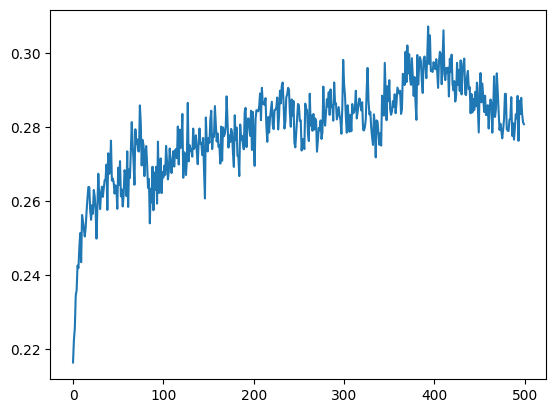

In [56]:
import matplotlib.pyplot as plt
plt.plot(history1.history["loss"])

In [38]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
## mini batch
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history2 = model.fit(x_scaled,y,epochs=500,batch_size=250,validation_split=0.2)
print(f"{time.time() - start} is the time taken by Mini Batch gradient descent in 500x2 epochs")

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9187 - loss: 0.2065 - val_accuracy: 0.9375 - val_loss: 0.2473
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9187 - loss: 0.2036 - val_accuracy: 0.9500 - val_loss: 0.2406
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9156 - loss: 0.2034 - val_accuracy: 0.9500 - val_loss: 0.2378
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9156 - loss: 0.2037 - val_accuracy: 0.9500 - val_loss: 0.2411
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9125 - loss: 0.2035 - val_accuracy: 0.9375 - val_loss: 0.2456
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9219 - loss: 0.2030 - val_accuracy: 0.9375 - val_loss: 0.2493
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9187 - loss: 0.2032 - val_accuracy: 0.9500 - val_loss: 0.2422
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9187 - loss: 0.2033 - val_accuracy: 0.9500 - val_loss

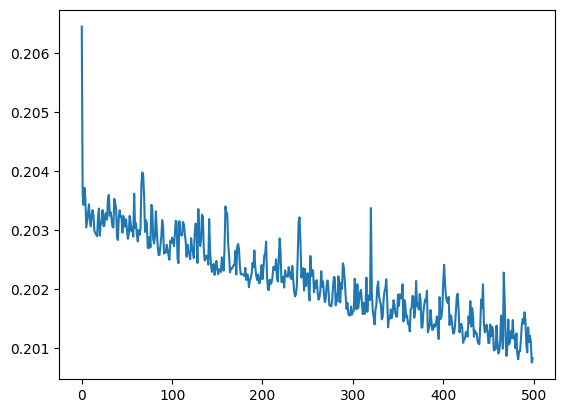

In [54]:
plt.plot(history2.history["loss"])

In [43]:
df.shape

(400, 5)

In [48]:
## Batch gradient descent
model = Sequential()
model.add(Dense(10,activation = "relu",input_dim=2))
model.add(Dense(10,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.compile(loss="binary_crossentropy",metrics=["accuracy"])
start = time.time()
history3 = model.fit(x_scaled,y,epochs=500,batch_size=400,validation_split=0.2)
print(f"{time.time() - start} is the time taken by Batch gradient descent in 500 epochs")

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step - accuracy: 0.9125 - loss: 0.2166 - val_accuracy: 0.9250 - val_loss: 0.2415
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9062 - loss: 0.2167 - val_accuracy: 0.9500 - val_loss: 0.2312
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9156 - loss: 0.2165 - val_accuracy: 0.9375 - val_loss: 0.2390
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9125 - loss: 0.2164 - val_accuracy: 0.9375 - val_loss: 0.2341
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9125 - loss: 0.2163 - val_accuracy: 0.9375 - val_loss: 0.2371
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9125 - loss: 0.2162 - val_accuracy: 0.9375 - val_loss: 0.2346
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9125 - loss: 0.2161 - val_accuracy: 0.9375 - val_loss: 0.2374
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9125 - loss: 0.2161 - val_accuracy: 0.9375 - val_loss

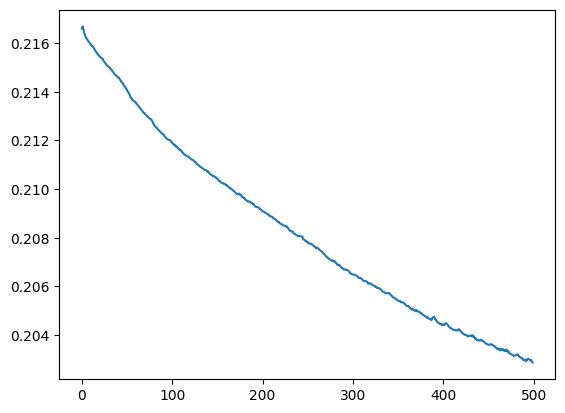

In [52]:
plt.plot(history3.history["loss"])

We can see the time the three optimizers took to converge to the optimal values.

In [59]:
print("SGD : 260.56169962882996 where #epochs = 500x320, loss = 0.28")
print("BGD : 37.86468958854675 where #epochs = 500, loss = 0.20")
print("MBGD : 40.733736991882324 where #epochs = 500x2, loss = 0.20")

SGD : 260.56169962882996 where #epochs = 500x320, loss = 0.28
BGD : 37.86468958854675 where #epochs = 500, loss = 0.20
MBGD : 40.733736991882324 where #epochs = 500x2, loss = 0.20


Stochastic Gradient Descent (SGD):

1. Time: 260.56 seconds. This is significantly longer than the other two methods.
2. Effective Epochs (Updates): 500 x 320 implies 500 epochs, with 320 weight updates per epoch (since batch_size=1 and you have 320 training samples after validation_split). This means a total of 160,000 weight updates.
3. Loss: 0.28. This is the highest final loss among the three.
Interpretation: SGD is the slowest in terms of wall-clock time and results in the highest loss. This is characteristic of SGD because it makes many noisy updates (one per sample) per epoch, leading to a long training time and a less stable convergence path, which can sometimes settle at a higher local minimum or oscillate more around the minimum.

Batch Gradient Descent (BGD):

1. Time: 37.86 seconds. This is the fastest training time.
Effective Epochs (Updates): 500 implies 500 epochs, with 1 weight update per epoch (since batch_size=400 means the entire training set of 320 samples is treated as one batch). This means a total of 500 weight updates.
2. Loss: 0.20. This is the lowest final loss.
3. Interpretation: BGD is the fastest and achieves the lowest loss. This is because it computes the gradient over the entire training set before making a single weight update per epoch. This leads to very stable and direct convergence towards the minimum. However, for much larger datasets, computing the gradient over the entire dataset can become computationally prohibitive and memory-intensive per update.


Mini-Batch Gradient Descent (MBGD):

1. Time: 40.73 seconds. This is only slightly slower than BGD.
Effective Epochs (Updates): 500 x 2 implies 500 epochs, with 2 weight updates per epoch (since batch_size=250 for 320 training samples, resulting in two batches). This means a total of 1,000 weight updates.
2. Loss: 0.20. This is also the lowest final loss, similar to BGD.
3. Interpretation: MBGD strikes a good balance. It's nearly as fast as BGD and achieves the same low loss. It performs more updates than BGD but fewer and less noisy updates than SGD, providing a good trade-off between computational efficiency and convergence stability. This makes it generally the most preferred optimization strategy in practice for larger datasets.